Step 0: Data Cleaning and preparation


This notebook analyzes the results from the multi-objective and baseline runs. It performs the following steps:



*  Loading and filtering data: Reads the ChEMBL activity data CSV file and selects relevant columns.
*   Converting units: Converts bioactivity values to nanomolar (nM) units.
*   Calculating pEC50: Calculates pEC50 values from the converted bioactivity data.
*   Assigning confidence classes: Assigns confidence levels based on pChEMBL values.
*   Handling duplicates and standardizing molecules: Identifies and filters duplicate compounds, removes salts and neutralizes charges from molecular structures, and canonicalizes SMILES strings to represent molecules uniquely.
*   Classifying compounds: Assigns compounds as 'Active', 'Inactive', 'Check', or 'Undefined' based on pEC50 values and ratios of active classifications.
*   Splitting data: Splits the data into training and testing sets and adds a flag column to indicate the split.
*   Visualizing data: Uses chemplot to visualize the data, for exploring chemical space and activity distribution.





In [2]:
# Install necessary libraries
!pip install chemplot rdkit bokeh jupyter_bokeh matplotlib seaborn scipy pandas numpy

# Import necessary libraries
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, PandasTools, MolStandardize, rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover
from IPython.display import display

# Corrected import based on traceback
try:
    from chemplot import Plotter
except ImportError:
    print("chemplot not found. Please install it using !pip install chemplot")

import seaborn as sns
from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool
from bokeh.io import output_notebook

# Set matplotlib backend
%matplotlib inline

In [3]:
# Read the CSV file downloaded through ChEMBL-Associated Bioactivities into a DataFrame
df = pd.read_csv('EC50_DB_FXR.csv', sep=';')

df.columns

# Filter for columns you need
df=df[['Molecule ChEMBL ID','Smiles', 'Standard Type', 'Standard Relation', 'Standard Value',
       'Standard Units', 'pChEMBL Value', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type',
       'BAO Label']]

# Count each 'Assay ChEMBL ID'
assay_counts = df['Assay ChEMBL ID'].value_counts().reset_index()
assay_counts.columns = ['Assay ChEMBL ID', 'Count']
assay_counts.to_csv('assay_counts_FXR.csv', index=False)
# Display the first few rows of the DataFrame to check
print(assay_counts)

    Assay ChEMBL ID  Count
0      CHEMBL840248    102
1     CHEMBL4408862     69
2     CHEMBL1041790     56
3     CHEMBL4040778     54
4     CHEMBL4820034     47
..              ...    ...
180   CHEMBL5247731      1
181   CHEMBL5236188      1
182   CHEMBL5247733      1
183   CHEMBL5247727      1
184   CHEMBL5236178      1

[185 rows x 2 columns]


In [4]:
# Function for values conversion being datas in Chembl mixed between nM and µM
def convert_to_nM(unit, bioactivity):
    """
    Convert bioactivity values to nanomolar (nM) units.

    Parameters:
    unit (str): The current unit of the bioactivity value.
    bioactivity (float): The bioactivity value to convert.

    Returns:
    float: The bioactivity value in nM units.
    """
    conversion_factors = {
        'uM': 1e3,
        "10'8nM": 1e8,
        "10'13nM": 1e13
    }
    return bioactivity * conversion_factors.get(unit, 1)

# Apply the conversion to the DataFrame
df['Standard Value'] = df.apply(
    lambda row: convert_to_nM(row['Standard Units'], row['Standard Value']),
    axis=1
)
df['Standard Units'] = 'nM'

In [5]:
# Calculate pEC50 values round them at the second decimal value and create a new column for them
df['pEC50'] = round(-np.log10(df['Standard Value'] * 1e-9), 2)
df['New Standard Type'] = 'pEC50'


# Fill NaN or null values with 4
df['pEC50'] = df['pEC50'].apply(lambda x: 4 if pd.isna(x) or x == 'invalid' else x)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
def assign_confidence_class(df):
    """
    Assigns a confidence class based on the pChEMBL Value for each compound in the DataFrame.

    Parameters:
    df (DataFrame): A DataFrame containing activity types and their values for compounds.

    Returns:
    DataFrame: The original DataFrame with an added column for the confidence class.
    """
    confidence_classes = {'A': 'High Confidence', 'B': 'Medium Confidence', 'C': 'Low Confidence', 'D': 'Very Low Confidence'}
    df['Confidence Class'] = 'D'  # Default to 'Very Low Confidence'

    for index, row in df.iterrows():
        if pd.notnull(row['pChEMBL Value']):
            p_value = (row['pChEMBL Value'])
            # Assign confidence class based on pValue
            if p_value >= 7:
                df.at[index, 'Confidence Class'] = 'A'
            elif p_value >= 5:
                df.at[index, 'Confidence Class'] = 'B'
            elif p_value <= 5:
                df.at[index, 'Confidence Class'] = 'C'
            else:
                df.at[index, 'Confidence Class'] = 'D'

    return df

# Modify the data to include the confidence class assignment
df_assay_confidenceclass = assign_confidence_class(df)

In [7]:
def find_duplicate_compounds(df_assay_confidenceclass):
    uniques = df_assay_confidenceclass.drop_duplicates(subset=['Assay ChEMBL ID', 'Molecule ChEMBL ID'],keep=False)
    duplicates = df_assay_confidenceclass[~df_assay_confidenceclass.index.isin(uniques.index)].sort_values(by= 'Molecule ChEMBL ID')
    duplicates['Activity Difference']= duplicates.groupby(['Assay ChEMBL ID', 'Molecule ChEMBL ID'])["Standard Value"].diff().fillna(0)
    duplicates_filtered = duplicates.loc[(abs(duplicates['Activity Difference']) <= 100) & ((duplicates['Activity Difference']) != 0) ]
    tot_df = pd.concat([duplicates_filtered,uniques])
    return tot_df


df_assay_curated = find_duplicate_compounds(df_assay_confidenceclass)

In [8]:
# Inizialise the SaltRemover
desalt = SaltRemover()
# Remove salts from molecules
df_assay_curated['mol'] = df_assay_curated['Smiles'].apply(Chem.MolFromSmiles)
df_assay_curated['no_salt'] = df_assay_curated['mol'].apply(desalt)

In [9]:
# Function to neutralize charges in molecules
def neutralise_charges(mol, reactions=None):
    if reactions is None:
        reactions = [
            # Imidazoles
            ('[n+;H]', 'n'),
            # Amines
            ('[N+;!H0]', 'N'),
            # Carboxylic acids and alcohols
            ('[$([O-]);!$([O-][#7]);!$([O-][S+])]', 'O'),
            # Thiols
            ('[S-;X1]', 'S'),
            # Sulfonamides
            ('[$([N-;X2]S(=O)=O)]', 'N'),
            # Enamines
            ('[$([N-;X2][C,N]=C)]', 'N'),
            # Tetrazoles
            ('[n-]', '[nH]'),
            # Sulfoxides
            ('[$([S-]=O)]', 'S'),
            # Amides
            ('[$([N-]C=O)]', 'N'),
        ]
        reactions = [(Chem.MolFromSmarts(x), Chem.MolFromSmiles(y, False)) for x, y in reactions]

    replaced = False
    for reactant, product in reactions:
        while mol.HasSubstructMatch(reactant):
            replaced = True
            rms = AllChem.ReplaceSubstructs(mol, reactant, product)
            mol = rms[0]
    if replaced:
        return Chem.MolToSmiles(mol, True)
    else:
        return Chem.MolToSmiles(mol, True)



In [10]:
# Apply the neutralization function to the molecules
df_assay_curated['neutral_smiles'] = df_assay_curated['no_salt'].apply(neutralise_charges)

In [11]:
# Drop unnecessary columns and display the updated DataFrame (to be updated)
df_assay_curated.drop(['no_salt', 'mol'], axis=1, inplace=True)
display(df_assay_curated.head())
# Display the first few rows of the updated DataFrame

,Molecule ChEMBL ID,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,pChEMBL Value,Assay ChEMBL ID,Assay Description,Assay Type,BAO Label,pEC50,New Standard Type,Confidence Class,Activity Difference,neutral_smiles
1120,CHEMBL187456,COC(=O)/C=C/c1cccc(N(Cc2ccc(-c3cccc(OC)c3)cc2)...,EC50,'=',101.0,nM,7.00,CHEMBL840248,Effective concentration against farnesoid X re...,B,single protein format,7.00,pEC50,A,24.0,COC(=O)/C=C/c1cccc(N(Cc2ccc(-c3cccc(OC)c3)cc2)...
0,CHEMBL601459,CC(C)OC(=O)C1=CN(C(=O)c2cccc(OCCCN(C)C)c2)CC(C...,EC50,'=',617.0,nM,6.21,CHEMBL1070842,Agonist activity at human FXR-LBD expressed in...,F,cell-based format,6.21,pEC50,B,NaN,CC(C)OC(=O)C1=CN(C(=O)c2cccc(OCCCN(C)C)c2)CC(C...
1,CHEMBL602061,CC(C)OC(=O)C1=CN(C(=O)c2cccc(OCCCN3CCOCC3)c2)C...,EC50,'=',796.0,nM,6.10,CHEMBL1070842,Agonist activity at human FXR-LBD expressed in...,F,cell-based format,6.10,pEC50,B,NaN,CC(C)OC(=O)C1=CN(C(=O)c2cccc(OCCCN3CCOCC3)c2)C...
2,CHEMBL3138091,C[C@H](CCNC(=O)OCc1ccc(C(=O)O)cc1)C1CC[C@H]2[C...,EC50,'=',7110.0,nM,5.15,CHEMBL854499,Binding affinity to FXR assessed as ligand-dep...,F,assay format,5.15,pEC50,B,NaN,C[C@H](CCNC(=O)OCc1ccc(C(=O)O)cc1)C1CC[C@H]2[C...
3,CHEMBL319606,Cc1cc(OCc2c(-c3c(Cl)cccc3Cl)noc2C(C)C)cc(C)c1/...,EC50,'=',37.0,nM,7.43,CHEMBL681097,Ligand dependent recruitment of SRC1(676-700) ...,B,single protein format,7.43,pEC50,A,NaN,Cc1cc(OCc2c(-c3c(Cl)cccc3Cl)noc2C(C)C)cc(C)c1/...


In [12]:
# Check which ChEMBL IDs do not have a specific assay format
Assay_Chembl_ID_to_check = set(df_assay_curated[(df_assay_curated['BAO Label'] == 'assay format')\
                                   & (df_assay_curated['New Standard Type'] == 'pEC50')]['Assay ChEMBL ID'].tolist())
Assay_Chembl_ID_to_check

{'CHEMBL1250097',
 'CHEMBL1670707',
 'CHEMBL1678687',
 'CHEMBL1738629',
 'CHEMBL1921084',
 'CHEMBL2065432',
 'CHEMBL2161911',
 'CHEMBL5247731',
 'CHEMBL854499',
 'CHEMBL974376',
 'CHEMBL980674',
 'CHEMBL984652'}

In [13]:
# Check what´assay format´ is in Bao Label to manually check the kind of assay
df_assay_curated[df_assay_curated['Assay ChEMBL ID'].isin(Assay_Chembl_ID_to_check)].\
groupby('Assay ChEMBL ID', as_index = False).\
agg({'Assay Description':'unique'}).values

array([['CHEMBL1250097',
        array(['Agonist activity at FXR'], dtype=object)],
       ['CHEMBL1670707',
        array(['Agonist activity at Gal4-fused human FXR by luciferase reporter gene transactivation assay'],
              dtype=object)                                                                                  ],
       ['CHEMBL1678687',
        array(['Agonist activity at human FXR LBD assessed as SRC1 peptide recruitment by FRET assay'],
              dtype=object)                                                                            ],
       ['CHEMBL1738629',
        array(['PUBCHEM_BIOASSAY: Late stage results from the probe development effort to identify novel modulators of the Retinoic acid receptor-related Orphan Receptors (ROR). (Class of assay: screening) [Related pubchem assays (depositor defined):AID2139, AID2277] Panel member name: FXR'],
              dtype=object)                                                                                        

In [14]:
# Most commonly the ´assay format´ labels refer to FRET assays which are cell-based, if so proceed running this cell
# Define the constant for cell-based format
CELL_BASED_FORMAT = 'cell-based format'

# Update 'New BAO Label' for rows where 'Assay ChEMBL ID' is in the set
df_assay_curated['New BAO Label'] = df_assay_curated.apply(
    lambda row: CELL_BASED_FORMAT if row['Assay ChEMBL ID'] in Assay_Chembl_ID_to_check else row['BAO Label'],
    axis=1
)

# Display the head of the DataFrame to verify the changes
df_assay_curated[['Assay ChEMBL ID', 'BAO Label', 'New BAO Label']].head()

,Assay ChEMBL ID,BAO Label,New BAO Label
1120,CHEMBL840248,single protein format,single protein format
0,CHEMBL1070842,cell-based format,cell-based format
1,CHEMBL1070842,cell-based format,cell-based format
2,CHEMBL854499,assay format,cell-based format
3,CHEMBL681097,single protein format,single protein format


In [15]:
# Let´s make two seperate df for cell and target based assays

cell_based_df = df_assay_curated[df_assay_curated['New BAO Label'] == 'cell-based format'].copy()
single_protein_df = df_assay_curated[df_assay_curated['New BAO Label'] == 'single protein format'].copy()

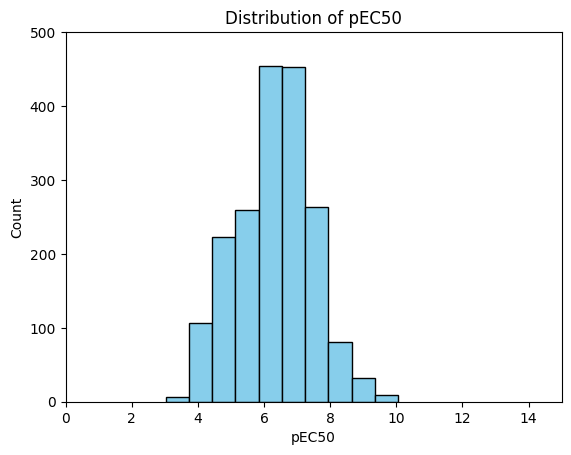

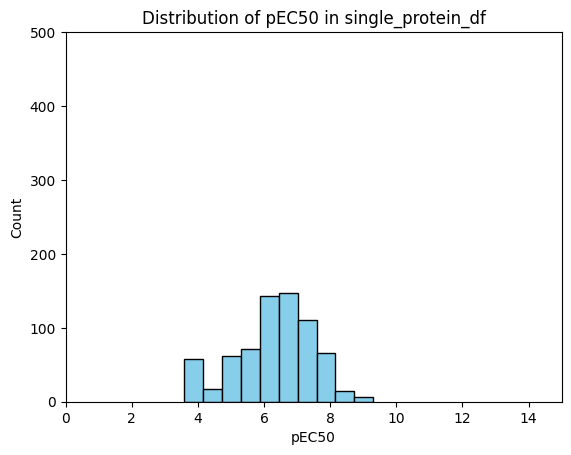

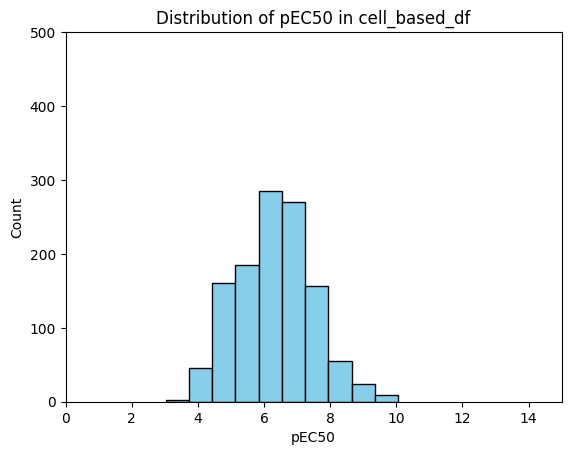

In [16]:
# Let´s try to see the distribuition of the data before going any further
# Distribuition plot
# Select only finite values (not NaN or inf)
finite_values = df_assay_curated['pEC50'][np.isfinite(df_assay_curated['pEC50'])]
plt.hist(finite_values, color='skyblue', edgecolor='black')
plt.xlabel('pEC50')
plt.ylabel('Count')
plt.xlim(0, 15)  # Set X-axis limits
plt.ylim(0, 500)  # Y-axis limits
plt.title('Distribution of pEC50')
plt.show()

# Distribuition plot for single_protein_df
plt.hist(single_protein_df['pEC50'], color='skyblue', edgecolor='black')
plt.xlim(0, 15)  # X-axis limits
plt.ylim(0, 500)  # Y-axis limits
plt.title('Distribution of pEC50 in single_protein_df')
plt.xlabel('pEC50')
plt.ylabel('Count')
plt.show()

# Distribuition plot for cell_based_df
finite_values_2 = cell_based_df['pEC50'][np.isfinite(cell_based_df['pEC50'])]
plt.hist(finite_values_2, color='skyblue', edgecolor='black')
plt.xlim(0, 15)  # X-axis limits
plt.ylim(0, 500)  # Y-axis limits
plt.title('Distribution of pEC50 in cell_based_df')
plt.xlabel('pEC50')
plt.ylabel('Count')
plt.show()

In [17]:
# Statistics on Dataset to have an insight on how to split the datasets between actives and inactives
try:
    grouped_data = df_assay_curated.groupby(['New BAO Label', 'New Standard Type', 'Standard Relation'])['pEC50'].describe(percentiles=[0.5])
    display(grouped_data)
except KeyError as e:
    print(f"KeyError: {e} not found in DataFrame columns.")


count      mean  \
New BAO Label         New Standard Type Standard Relation                     
cell-based format     pEC50             '<'                   9.0  6.902222   
                                        '='                1157.0       inf   
                                        '>'                  65.0  4.712154   
single protein format pEC50             '<'                  15.0  7.378667   
                                        '='                 574.0  6.563380   
                                        '>'                  67.0  5.116716   

                                                                std   min  \
New BAO Label         New Standard Type Standard Relation                   
cell-based format     pEC50             '<'                1.070301  5.00   
                                        '='                     NaN  3.03   
                                        '>'                0.413418  4.00   
single protein format pEC50             '<'                0.116733  7.30   
                                        '='                0.959367  3.59   
                                        '>'                0.778418  3.82   

                                                             50%   max  
New BAO Label         New Standard Type Standard Relation               
cell-based format     pEC50             '<'                7.000  9.00  
                                        '='                6.520   inf  
                                        '>'                5.000  5.73  
single protein format pEC50             '<'                7.300  7.60  
                                        '='                6.635  9.30  
                                        '>'                5.000  6.00

In [19]:
# Function to canonicalize SMILES with chirality and without (comment or uncomment as needed) and remove tautomers
def canonicalize_smiles(smiles):
    # Standardize the molecule and get the tautomer canonical form
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # Import TautomerCanonicalizer directly
        from rdkit.Chem.MolStandardize import TautomerCanonicalizer
        enumerator = TautomerCanonicalizer()
        mol = enumerator.canonicalize(mol)
        # Convert to canonical SMILES with chirality
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None



#def canonicalize_smiles_without_chirality(smiles):
#    mol = Chem.MolFromSmiles(smiles)
#    if mol is None:
#        raise ValueError("Invalid SMILES string")
#    else:
        # Remove chirality information
#        for atom in mol.GetAtoms():
#            atom.SetChiralTag(Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
        # Convert to canonical SMILES with aromaticity preserved
#       canonical_smiles = Chem.MolToSmiles(mol, isomericSmiles=False)
#        return canonical_smiles



# Apply the function to the 'neutral_smiles' column
df_assay_curated['canonical_smiles'] = df_assay_curated['neutral_smiles'].apply(canonicalize_smiles)

ImportError: cannot import name 'TautomerCanonicalizer' from 'rdkit.Chem.MolStandardize' (/usr/local/lib/python3.12/dist-packages/rdkit/Chem/MolStandardize/__init__.py)

In [24]:
# Function to canonicalize SMILES with chirality and without (comment or uncomment as needed) and remove tautomers
def canonicalize_smiles(smiles):
    # Standardize the molecule and get the tautomer canonical form
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # Use RDKit's built-in tautomer enumerator
        from rdkit.Chem.MolStandardize import rdMolStandardize
        enumerator = rdMolStandardize.TautomerEnumerator()
        mol = enumerator.Canonicalize(mol)
        # Convert to canonical SMILES with chirality
        return Chem.MolToSmiles(mol, canonical=True)
    else:
        return None



#def canonicalize_smiles_without_chirality(smiles):
#    mol = Chem.MolFromSmiles(smiles)
#    if mol is None:
#        raise ValueError("Invalid SMILES string")
#    else:
        # Remove chirality information
#        for atom in mol.GetAtoms():
#            atom.SetChiralTag(Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
        # Convert to canonical SMILES with aromaticity preserved
#       canonical_smiles = Chem.MolToSmiles(mol, isomericSmiles=False)
#        return canonical_smiles



# Apply the function to the 'neutral_smiles' column
df_assay_curated['canonical_smiles'] = df_assay_curated['neutral_smiles'].apply(canonicalize_smiles)

In [25]:
# Assigning class threshold pEC50 based rule (Change the threshold as you need)
df_assay_curated['class'] = df_assay_curated['pEC50'].apply(lambda x: 1 if x >= 6.6 else 0)
df_assay_curated[['class', 'pEC50']].tail()

# Check if there are entries with class 0
has_class_0 = (df_assay_curated['class'] == 0).any()
print(f"Are there entries with class 0? {has_class_0}")
len(df_assay_curated)

Are there entries with class 0? True


1945

In [26]:
grouped = df_assay_curated.groupby(['canonical_smiles', 'New BAO Label'])

def most_frequent_and_ratio(group):
    most_frequent_class = group['class'].mode()[0]
    count_class = (group['class'] == 1).sum()
    total = len(group)
    ratio_class = count_class / total
    # Get the mean of the pEC50 values for the group
    mean_pEC50 = group['pEC50'].mean()
    return pd.Series({'most_frequent_class': most_frequent_class,
                      'ratio_class': ratio_class,
                      'pEC50': mean_pEC50})

result_df = grouped.apply(most_frequent_and_ratio).reset_index()

/tmp/ipython-input-1870329289.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_df = grouped.apply(most_frequent_and_ratio).reset_index()


In [27]:
# Define a function to determine reclassification based on 'Class_Ratio'
def reclassify(ratio):
    if 0 <= ratio <= 0.3:
        return 'Inactive'
    elif 0.4 <= ratio <= 0.6:
        return 'Check'
    elif 0.7 <= ratio <= 1:
        return 'Active'
    else:
        return 'Undefined'  # In case the ratio is outside the specified ranges

# Apply the function to the 'Class_Ratio' column to create the 'Reclassification' column
result_df['Reclassification'] = result_df['ratio_class'].apply(reclassify)


In [28]:
# Check if there are entries with Check
has_to_be_checked = (result_df['Reclassification'] == 'Check').any()
print(f"Are there entries to be checked? {has_to_be_checked}")

# Count the occurrences of each category in the 'Reclassification' column
category_counts = result_df['Reclassification'].value_counts()

# Display the counts for each category
print(category_counts)

check_rows = result_df[result_df['Reclassification'] == 'Check']

# Display the rows with 'Reclassification' as 'Check'
print(check_rows)

Are there entries to be checked? True
Reclassification
Inactive     933
Active       689
Check         16
Undefined      3
Name: count, dtype: int64
                                       canonical_smiles  \
337   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(-c2ccc3[n...   
347   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(-c2ccc3c(...   
355   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(-c2ccc3cc...   
361   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(-c2ccc3nc...   
436   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(N(C)C(=O)...   
448   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(N(C)Cc2cc...   
450   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(N(C)Cc2cc...   
452   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(N(C)Cc2cc...   
459   CC(C)c1onc(-c2c(Cl)cccc2Cl)c1COc1ccc(NCc2ccc(C...   
513   CC(C)c1onc(-c2c(Cl)cncc2Cl)c1COc1ccc(/C=C/c2cc...   
611   CC(Nc1ccc(C(=O)O)cc1)c1ccc(OCc2c(-c3c(Cl)cccc3...   
613   CC(Oc1ccc(C(=O)O)cc1)c1ccc(OCc2c(-c3c(Cl)cccc3...   
701   CCOC(=O)NCC[C@@H](C)[C@H]1CC[C@H]2[C@@H]3[C@H]...   
1037  COc1cccc(OC)c1-c1no

In [29]:
# Update 'Reclassification' column based on conditions
result_df.loc[(result_df['Reclassification'] == 'Check') & (result_df['ratio_class'] == 0.5), 'Reclassification'] = 'Inactive'

# Add Binary Values for active/inactives
result_df['BooleanClassification'] = result_df['Reclassification'].apply(lambda x: 1 if x == 'Active' else 0)
#duplicateRows = result_df[result_df.duplicated(['canonical_smiles', 'New BAO Label'])]

display(result_df)

,canonical_smiles,New BAO Label,most_frequent_class,ratio_class,pEC50,Reclassification,BooleanClassification
0,Brc1ccc(-c2nc(-c3ccccc3)no2)cc1,cell-based format,0.0,0.0,6.46,Inactive,0
1,Brc1ccc2nc(-c3cccs3)c(NCc3ccccc3)n2c1,cell-based format,0.0,0.0,6.30,Inactive,0
2,C#CC[C@@H]1C2C[C@H](O)CC[C@]2(C)[C@H]2CC[C@]3(...,single protein format,0.0,0.0,6.27,Inactive,0
3,C/C(=N\OCc1cc(C(=O)O)ccc1C#N)c1ccc(OCc2c(-c3c(...,cell-based format,1.0,1.0,7.34,Active,1
4,C/C(=N\OCc1cc(C(=O)O)ccc1C#N)c1ccc(OCc2c(-c3cc...,cell-based format,0.0,0.0,6.36,Inactive,0
...,...,...,...,...,...,...,...
1636,O=S(O)c1cc(F)c2nc(N3[C@@H]4CC[C@H]3C[C@@H](OCc...,cell-based format,0.0,0.0,6.30,Inactive,0
1637,c1ccc(-c2noc(-c3ccccc3)n2)cc1,cell-based format,0.0,0.0,6.28,Inactive,0
1638,c1ccc(CNc2c(-c3cccs3)nc3ccc(-c4ccccc4)cn23)cc1,cell-based format,1.0,1.0,6.70,Active,1
1639,c1ccc(CNc2c(-c3cccs3)nc3ccccn23)cc1,cell-based format,0.0,0.0,5.40,Inactive,0


In [30]:
category_counts = result_df['Reclassification'].value_counts()
print(category_counts)

Reclassification
Inactive     949
Active       689
Undefined      3
Name: count, dtype: int64


In [33]:
def split_data_in_place_with_flag(data, flag_value="- 1", test_size=0.1, col_name="pEC50"):
  """
  Modifies a pandas DataFrame to include a flag column for training and testing,
  splitting the data in-place.

  Args:
      data (pandas.DataFrame): The DataFrame to modify and split.
      flag_value (str, optional): The value to use in the new flag column to indicate
                                  data points used only for training (default: "- 1").
      test_size (float, optional): The proportion of data to be used for the test set (default: 0.1).

  Returns:
      pandas.DataFrame: The modified DataFrame with the flag column and split data.
  """

  # Create a new flag column with the specified value
  data['flag'] = flag_value

  # Set the flag to '0' (not for training only) for data points with numeric labels
  data.loc[data[col_name].notna(), 'flag'] = '0'

  # Split the data into training and testing sets based on the flag column (in-place)
  train_indices, test_indices = train_test_split(data.index, test_size=test_size, random_state=42)
  data.loc[train_indices, 'flag'] = '-1'  # Set flag to '0' for training set (in-place)

  return data


data_with_flag = split_data_in_place_with_flag(result_df.copy())

print("Data with flag column:")
print(data_with_flag)



Data with flag column:
                                       canonical_smiles  \
0                       Brc1ccc(-c2nc(-c3ccccc3)no2)cc1   
1                 Brc1ccc2nc(-c3cccs3)c(NCc3ccccc3)n2c1   
2     C#CC[C@@H]1C2C[C@H](O)CC[C@]2(C)[C@H]2CC[C@]3(...   
3     C/C(=N\OCc1cc(C(=O)O)ccc1C#N)c1ccc(OCc2c(-c3c(...   
4     C/C(=N\OCc1cc(C(=O)O)ccc1C#N)c1ccc(OCc2c(-c3cc...   
...                                                 ...   
1636  O=S(O)c1cc(F)c2nc(N3[C@@H]4CC[C@H]3C[C@@H](OCc...   
1637                      c1ccc(-c2noc(-c3ccccc3)n2)cc1   
1638     c1ccc(CNc2c(-c3cccs3)nc3ccc(-c4ccccc4)cn23)cc1   
1639                c1ccc(CNc2c(-c3cccs3)nc3ccccn23)cc1   
1640                c1ccc(CNc2c(-c3cccs3)nc3cnccn23)cc1   

              New BAO Label  most_frequent_class  ratio_class  pEC50  \
0         cell-based format                  0.0          0.0   6.46   
1         cell-based format                  0.0          0.0   6.30   
2     single protein format                  0.0    

In [34]:
# Check the proportions of flags
training_proportion = (data_with_flag['flag'] == '-1').mean()
test_proportion = (data_with_flag['flag'] == '0').mean()

print(f"Training set proportion: {training_proportion:.2%}")
print(f"Test set proportion: {test_proportion:.2%}")


Training set proportion: 89.95%
Test set proportion: 10.05%


In [35]:
data_with_flag.to_csv('cleanedDB.csv', index=False)

In [ ]:
cp = Plotter.from_smiles(result_df["canonical_smiles"], target=result_df["BooleanClassification"], target_type="C", sim_type="structural")
cp.pca()
cp.visualize_plot()